In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('Steel_indastry_procc.csv')
df.head()

,Unnamed: 0,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_Of_Week,Load_Type,Hour,DayOfWeek
0,0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0
1,1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0
2,2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,0
3,3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,0
4,4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,0


Готовим наши колонки для преобразования. Числовые - нормализуем, Категориальные - преобразуем в числовые.

In [4]:
cat_features = ['WeekStatus', 'Day_Of_Week', 'Load_Type']
numb_features = ['Leading_Current_Reactive_Power_kVarh', 
                 'Lagging_Current_Power_Factor',
                 'Leading_Current_Power_Factor',
                 'NSM',
                 'DayOfWeek']

X = df[numb_features + cat_features]
y = df['Usage_kWh']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

У нас есть числовые и категориальные. Для удобства собираем их в препроцесор в котором указываем каким, какой вид преобразования

In [5]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),numb_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

Автоматизируем наши процесы обработки, обучения в эдиную структуру

In [6]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regresor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

In [7]:
param_grid = {
    'regresor__n_estimators':[50, 100, 200],
    'regresor__max_depth': [5, 10, 20],
    'regresor__min_samples_split':[2, 15]
}



In [8]:
tscv = TimeSeriesSplit(n_splits= 7)
grid_search = GridSearchCV(pipeline, param_grid, cv= tscv, scoring= 'r2', n_jobs= -1, verbose= 1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
val_score = grid_search.best_score_
test_score = best_model.score(X_test, y_test)
best_param = grid_search.best_params_

print(f'''r2 точность (кросс) - {val_score}
        r2 (тестовые данные)  - {test_score}
        Лучшие параметры - {best_param}''')


Fitting 7 folds for each of 18 candidates, totalling 126 fits
r2 точность (кросс) - 0.8568407258079889
        r2 (тестовые данные)  - 0.862202881483763
        Лучшие параметры - {'regresor__max_depth': 10, 'regresor__min_samples_split': 2, 'regresor__n_estimators': 200}


In [9]:
best_param

{'regresor__max_depth': 10,
 'regresor__min_samples_split': 2,
 'regresor__n_estimators': 200}

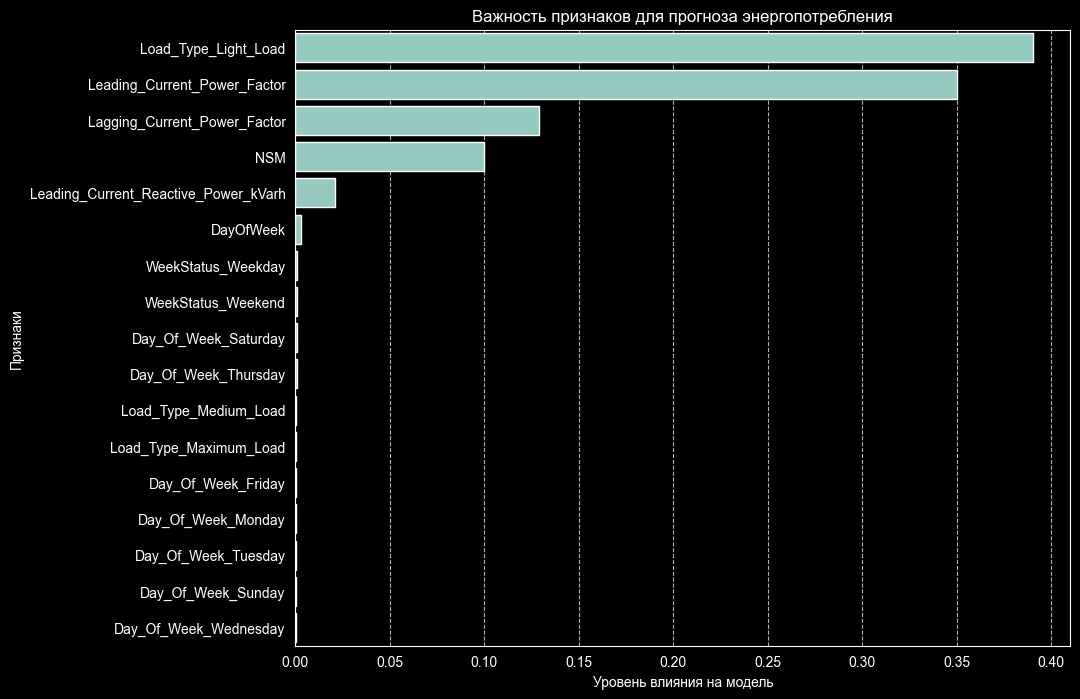

In [10]:
preprocessor = grid_search.best_estimator_.named_steps['preprocessor']
cat_encoder = preprocessor.named_transformers_['cat']
cat_columns = list(cat_encoder.get_feature_names_out(cat_features))

full_feature_names = numb_features + cat_columns

importances = grid_search.best_estimator_.named_steps['regresor'].feature_importances_


importance_df = pd.DataFrame({
    'Feature': full_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Важность признаков для прогноза энергопотребления')
plt.xlabel('Уровень влияния на модель')
plt.ylabel('Признаки')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('importance_feature.png')
plt.show()

In [14]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'MAE -> {mae:.3f}\n'
      f'RMSE -> {rmse:.3f}')

MAE -> 6.075
RMSE -> 11.977


In [81]:
import joblib

In [92]:
final_model = best_model
joblib.dump(final_model, 'my_model.joblib')

['my_model.joblib']